In [1]:
import sys
import os

sys.path.append("..")
sys.path.append("../..")
sys.path.append("../../..")

In [2]:
os.makedirs("./logs/joint/", exist_ok=True)
os.makedirs("./figs/env/", exist_ok=True)
os.makedirs("./figs/exp/joint/", exist_ok=True)

In [3]:
%load_ext autoreload
%autoreload 2

import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import sklearn

from experiment.utils.utils import logit

from typing import Literal

In [4]:
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [5]:
import hydra
from hydra import initialize, compose
from hydra.core.global_hydra import GlobalHydra


GlobalHydra.instance().clear()
initialize(version_base=None, config_path="../../config")

config = compose(config_name="config")

print(config)

{'common': {'seed': 42}, 'algorithms': {'denoise_bid': {'ctr_only': {'xdgmm': {'max_iter': 300, 'tol': 0.0001}, 'mosek': {'tol_pfeas': 1e-08, 'tol_dfeas': 1e-08, 'tol_rel_gap': 1e-08, 'tol_mu_red': 1e-08}}, 'joint': {'gh_approximation': {'n_quad_points': 5}, 'xdgmm': {'max_iter': 300, 'tol': 0.0001}, 'mosek': {'tol_pfeas': 1e-08, 'tol_dfeas': 1e-08, 'tol_rel_gap': 1e-08, 'tol_mu_red': 1e-08}}}, 'non_robust_bid': {'mosek': {'tol_pfeas': 1e-08, 'tol_dfeas': 1e-08, 'tol_rel_gap': 1e-08, 'tol_mu_red': 1e-08}}, 'robust_bid': {'k_sigmas': 3, 'mosek': {'tol_pfeas': 1e-08, 'tol_dfeas': 1e-08, 'tol_rel_gap': 1e-08, 'tol_mu_red': 1e-08}}}}


# Environment Sampling

In [6]:
NUM_AUCTIONS = 500

In [7]:
def price2bin(price):
    """
    price = 1.2 ** bin
    """
    if price <= 0:
        return 0
    return np.round(np.log(price) / np.log(1.2))

def bin2price(bin_):
    return np.power(1.2, bin_)

In [8]:
from datasets import load_dataset, load_from_disk
if not os.path.exists("../../data/BAT/vcg_campaigns") or not os.path.exists("../../data/BAT/vcg_stats"):
    vcg_campaigns = load_dataset("AvitoTech/BAT", "vcg_campaigns")
    vcg_stats = load_dataset("AvitoTech/BAT", "vcg_stats")

    vcg_campaigns.save_to_disk("../../data/BAT/vcg_campaigns")
    vcg_stats.save_to_disk("../../data/BAT/vcg_stats")

/Users/iazhigalsky/work/denoise-bid-uai26/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
VCG_CAMPAIGNS = load_from_disk("../../data/BAT/vcg_campaigns")
VCG_STATS = load_from_disk("../../data/BAT/vcg_stats")

In [10]:
VCG_STATS_SUBSAMPLE_DF = pd.DataFrame(VCG_STATS["train"][:10_000_000])
VCG_STATS_SUBSAMPLE_DF = VCG_STATS_SUBSAMPLE_DF[VCG_STATS_SUBSAMPLE_DF["CTRPredicts"] >= 1e-9].reset_index()
VCG_CAMPAIGNS_DF = pd.DataFrame(VCG_CAMPAIGNS["train"])

unique_campaign_ids = VCG_STATS_SUBSAMPLE_DF["campaign_id"].unique()

VCG_CAMPAIGNS_SUBSAMPLE_DF = VCG_CAMPAIGNS_DF[
    VCG_CAMPAIGNS_DF["campaign_id"].isin(unique_campaign_ids)
].reset_index()

In [11]:
mask = VCG_STATS_SUBSAMPLE_DF.groupby("campaign_id")["AuctionCount"].transform("count") >= NUM_AUCTIONS
VCG_STATS_SUBSAMPLE_DF_FILTERED = VCG_STATS_SUBSAMPLE_DF[mask].copy().reset_index(drop=True)
CAMPAIGN_IDS = VCG_STATS_SUBSAMPLE_DF_FILTERED["campaign_id"].unique()

In [12]:
CAMPAIGN_IDS.shape

(334,)

In [13]:
def sample_campaign(
    seed,
    campaign_id,
    sigma_ctr = 0.0,
    sigma_cvr = 0.0,
    vcg_stats_df = VCG_STATS_SUBSAMPLE_DF_FILTERED,
):
    rng = np.random.default_rng(seed)
    campaign = vcg_stats_df[vcg_stats_df["campaign_id"] == campaign_id]

    weights = np.array(campaign["AuctionCount"], dtype=np.float64)
    weights /= weights.sum()

    idxs = rng.choice(len(campaign), size=len(campaign), p=weights, replace=True)
    logs = vcg_stats_df.iloc[idxs]

    place_count = logs["AuctionCount"]
    ctr_clean = np.array(logs["CTRPredicts"] / place_count)
    cvr_clean = np.array(logs["CRPredicts"] / place_count)
    # wp = np.array((logs["AuctionWinBidSurplus"] + bin2price(logs["contact_price_bin"])) / place_count)
    wp = np.array(bin2price(logs["contact_price_bin"]) / place_count)

    ctr_clean_logit = logit(ctr_clean)
    cvr_clean_logit = logit(cvr_clean)
    ctr_noised_logit = ctr_clean_logit + rng.normal(0, sigma_ctr, len(campaign))
    cvr_noised_logit = cvr_clean_logit + rng.normal(0, sigma_cvr, len(campaign))

    return ctr_clean_logit, ctr_noised_logit, cvr_clean_logit, cvr_noised_logit, wp

## DISTRIBUTIONS hist

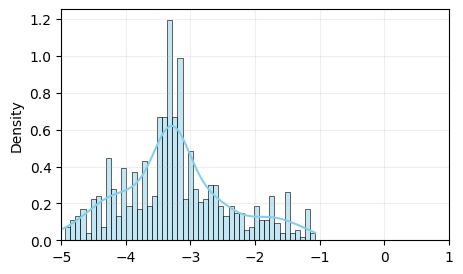

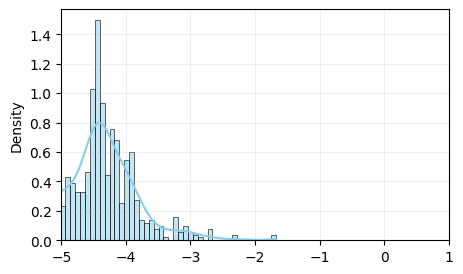

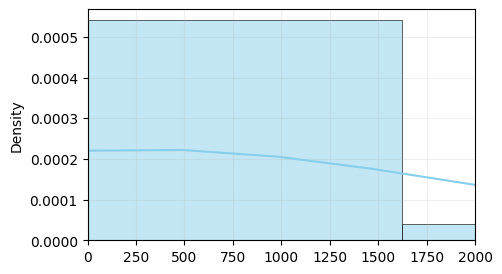

In [14]:
def visualize_samples(samples, figname, clip=[0, 1], logit_space=False):
    plt.figure(figsize=(5, 3))

    if logit_space:
        samples = logit(samples)
    sns.histplot(samples, bins=60, kde=True, stat="density", color='skyblue')

    plt.xlim(clip)

    plt.savefig(figname, format="pdf", bbox_inches="tight")
    plt.grid(alpha=0.2)
    plt.show()

ctr_data, _, cvr_data, _, wp = sample_campaign(
    seed = 1,
    campaign_id = CAMPAIGN_IDS[0],
    sigma_ctr=1e-1,
    sigma_cvr=1e-1,
)

visualize_samples(ctr_data, f"figs/env/ctr_{len(ctr_data)}samples.pdf", clip=[-5, 1])
visualize_samples(cvr_data, f"figs/env/cvr_{len(cvr_data)}samples.pdf", clip=[-5, 1])
visualize_samples(wp, f"figs/env/wp_{len(wp)}samples.pdf", clip=[0, 2_000])

In [15]:
from experiment.non_robust_bid.offline_bidder import non_robust_bid
# from experiment.denoise_bid.ctr_only.offline_bidder import denoise_bid as ctr_only_denoise_bid
from experiment.denoise_bid.joint.offline_bidder import denoise_bid as joint_denoise_bid
from experiment.robust_bid.offline_bidder import robust_bid

from experiment.non_robust_bid.lp import solve_dual as non_robust_dual
from experiment.non_robust_bid.bid import bids as non_robust_bids

from experiment.utils.utils import sigmoid

## Metrics calculation on clean environment

In [16]:
def simulate_offline_metrics(config, ctr_clean, cvr_clean, bids, wp, budget, target_cpc):
    is_win = bids >= wp
    total_conversions = float(np.sum(ctr_clean * cvr_clean * is_win))

    total_avg_cpc = wp.sum() / ctr_clean.sum()

    p, q = non_robust_dual(config.algorithms.non_robust_bid, ctr_clean, cvr_clean, wp, budget, target_cpc)
    opt_bids = non_robust_bids(ctr_clean, cvr_clean, p, q, target_cpc)
    opt_value = ((opt_bids > wp) * ctr_clean * cvr_clean).sum()
    value_ratio = total_conversions / opt_value

    total_cost = float(np.sum(wp * is_win))
    total_clicks = float(np.sum(ctr_clean * is_win))
    avg_cpc = total_cost / total_clicks if total_clicks > 0 else 0.0

    avg_cpc_ratio = avg_cpc / total_avg_cpc

    return {
        "total_conversions": value_ratio,
        "avg_cpc": avg_cpc_ratio,
    }

## Experiment function

In [17]:
def run_single_experiment(
    config,
    campaign_id: int,
    sigma_ctr: float,
    sigma_cvr: float,
    budget_proportion: float,
    target_cpc_proportion: float,
    bidder_mode: Literal["non-robust", "robust", "denoise"] = "non-robust",
    n_components = None,
):
    ctr_clean_logit, ctr_noised_logit, cvr_clean_logit, cvr_noised_logit, wp = sample_campaign(config.common.seed, campaign_id, sigma_ctr, sigma_cvr)

    ctr_clean = sigmoid(ctr_clean_logit)
    cvr_clean = sigmoid(cvr_clean_logit)
    ctr_noised = sigmoid(ctr_noised_logit)
    cvr_noised = sigmoid(cvr_noised_logit)

    budget = budget_proportion * wp.sum()
    target_cpc = target_cpc_proportion * wp.sum() / ctr_clean.sum()

    if bidder_mode == "non-robust":
        bids = non_robust_bid(config.algorithms.non_robust_bid, ctr_noised_logit, cvr_noised_logit, wp, budget, target_cpc)
        metrics = simulate_offline_metrics(
            config, ctr_clean, cvr_clean, bids, wp, budget, target_cpc
        )

    elif bidder_mode == "robust":
        rob_eps = np.sum((ctr_noised - ctr_clean)**2) / 2
        bids = robust_bid(
            config.algorithms.robust_bid,
            ctr_noised_logit,
            cvr_noised_logit,
            sigma_ctr,
            sigma_cvr,
            wp,
            budget,
            target_cpc,
            epsilon=rob_eps,
        )

        metrics = simulate_offline_metrics(
            config, ctr_clean, cvr_clean, bids, wp, budget, target_cpc,
        )

    elif bidder_mode == "denoise":
        bids = joint_denoise_bid(
            config.algorithms.denoise_bid.joint,
            ctr_noised_logit,
            cvr_noised_logit,
            np.ones_like(ctr_noised_logit) * sigma_ctr,
            np.ones_like(cvr_noised_logit) * sigma_cvr,
            wp,
            budget,
            target_cpc,
            n_components=n_components,
        )

        metrics = simulate_offline_metrics(
            config, ctr_clean, cvr_clean, bids, wp, budget, target_cpc,
        )

    return {
        "sigma_ctr": sigma_ctr,
        "sigma_cvr": sigma_cvr,
        "seed": config.common.seed,
        "metrics": metrics,
    }

### Experiment aggregating function

In [18]:
def aggregate_results(raw_path: str, summary_path: str):
    df = pd.read_csv(raw_path)
    grouped = (
        df.groupby(["sigma_ctr", "sigma_cvr"])
        .agg(
            total_conversions_mean=("conversions", "mean"),
            total_conversions_std=("conversions", "std"),
            avg_cpc_mean=("cpc", "mean"),
            avg_cpc_std=("cpc", "std"),
        )
        .reset_index()
    )
    grouped.to_csv(summary_path, index=False)
    return summary_path

# ALL ALGORITHMS COMPARISON

In [19]:
SIGMAS_CTR = np.logspace(-2, 1, 10)
SIGMAS_CVR = np.logspace(-2, 1, 10)

SIGMA_GRID = [(s_ctr, s_cvr) for s_ctr in SIGMAS_CTR for s_cvr in SIGMAS_CVR]
NUM_SEEDS = len(CAMPAIGN_IDS)

CAMPAIGN_IDS_SUBSAMPLE = CAMPAIGN_IDS[:NUM_SEEDS]
BUDGET_PROPORTION = 0.2
TARGET_CPC_PROPORTION = 0.2

In [ ]:
rows_non_robust = []
rows_robust = []
rows_normal = []
rows_2_comp = []

for sigma_ctr, sigma_cvr in tqdm(SIGMA_GRID):
    for camp_id in CAMPAIGN_IDS_SUBSAMPLE:
        try:
            exp_res_nr = run_single_experiment(config, camp_id, sigma_ctr, sigma_cvr, BUDGET_PROPORTION, TARGET_CPC_PROPORTION, bidder_mode="non-robust")
            exp_res_rb = run_single_experiment(config, camp_id, sigma_ctr, sigma_cvr, BUDGET_PROPORTION, TARGET_CPC_PROPORTION, bidder_mode="robust")
            exp_res_norm = run_single_experiment(config, camp_id, sigma_ctr, sigma_cvr, BUDGET_PROPORTION, TARGET_CPC_PROPORTION, bidder_mode="denoise", n_components=1)
            exp_res_gm2 = run_single_experiment(config, camp_id, sigma_ctr, sigma_cvr, BUDGET_PROPORTION, TARGET_CPC_PROPORTION, bidder_mode="denoise", n_components=2)

            rows_normal.append(
                {
                    "sigma_ctr": sigma_ctr,
                    "sigma_cvr": sigma_cvr,
                    "SEED": config.common.seed,
                    "conversions": exp_res_norm["metrics"]["total_conversions"],
                    "cpc": exp_res_norm["metrics"]["avg_cpc"],
                }
            )

            rows_2_comp.append(
                {
                    "sigma_ctr": sigma_ctr,
                    "sigma_cvr": sigma_cvr,
                    "SEED": config.common.seed,
                    "conversions": exp_res_gm2["metrics"]["total_conversions"],
                    "cpc": exp_res_gm2["metrics"]["avg_cpc"],
                }
            )

            rows_non_robust.append(
                {
                    "sigma_ctr": sigma_ctr,
                    "sigma_cvr": sigma_cvr,
                    "SEED": config.common.seed,
                    "conversions": exp_res_nr["metrics"]["total_conversions"],
                    "cpc": exp_res_nr["metrics"]["avg_cpc"],
                }
            )

            rows_robust.append(
                {
                    "sigma_ctr": sigma_ctr,
                    "sigma_cvr": sigma_cvr,
                    "SEED": config.common.seed,
                    "conversions": exp_res_rb["metrics"]["total_conversions"],
                    "cpc": exp_res_rb["metrics"]["avg_cpc"],
                }
            )
        except Exception as e:
            print(f"Error in seed {config.common.seed}, sigma {sigma_ctr}, {sigma_cvr}: {e}")
            continue


df_non_robust = pd.DataFrame(rows_non_robust)
df_robust = pd.DataFrame(rows_robust)
df_normal = pd.DataFrame(rows_normal)
df_2_comp = pd.DataFrame(rows_2_comp)

non_robust_all_path = f"logs/joint/nr_c{TARGET_CPC_PROPORTION}_b{BUDGET_PROPORTION}.csv"
robust_all_path = f"logs/joint/rb_c{TARGET_CPC_PROPORTION}_b{BUDGET_PROPORTION}.csv"
normal_all_path = f"logs/joint/norm_c{TARGET_CPC_PROPORTION}_b{BUDGET_PROPORTION}.csv"
gm_2_comp_all_path = f"logs/joint/gm2_c{TARGET_CPC_PROPORTION}_b{BUDGET_PROPORTION}.csv"

df_non_robust.to_csv(non_robust_all_path, index=False)
df_robust.to_csv(robust_all_path, index=False)
df_normal.to_csv(normal_all_path, index=False)
df_2_comp.to_csv(gm_2_comp_all_path, index=False)

In [ ]:
non_robust_summary_path = f"logs/joint/nr_c{TARGET_CPC_PROPORTION}_b{BUDGET_PROPORTION}_summary.csv"
robust_summary_path = f"logs/joint/rb_c{TARGET_CPC_PROPORTION}_b{BUDGET_PROPORTION}_summary.csv"
normal_summary_path = f"logs/joint/norm_c{TARGET_CPC_PROPORTION}_b{BUDGET_PROPORTION}_summary.csv"
gm_2_comp_summary_path = f"logs/joint/gm2_c{TARGET_CPC_PROPORTION}_b{BUDGET_PROPORTION}_summary.csv"

aggregate_results(non_robust_all_path, non_robust_summary_path)
aggregate_results(robust_all_path, robust_summary_path)
aggregate_results(normal_all_path, normal_summary_path)
aggregate_results(gm_2_comp_all_path, gm_2_comp_summary_path)

'logs/joint/gm2_c0.2_b0.2_summary.csv'

### *FIGURE*

In [ ]:
df_list_names = [
    f"logs/joint/nr_c{TARGET_CPC_PROPORTION}_b{BUDGET_PROPORTION}_summary.csv",
    f"logs/joint/rb_c{TARGET_CPC_PROPORTION}_b{BUDGET_PROPORTION}_summary.csv",
    f"logs/joint/norm_c{TARGET_CPC_PROPORTION}_b{BUDGET_PROPORTION}_summary.csv",
    f"logs/joint/gm2_c{TARGET_CPC_PROPORTION}_b{BUDGET_PROPORTION}_summary.csv",
]

exp_num = len(df_list_names)

name_fig = f"figs/exp/joint/b{BUDGET_PROPORTION}_c{TARGET_CPC_PROPORTION}.pdf"
c_arr = ["NonRobustBid", "RobustBid", "DenoiseBid\n(normal prior)", "DenoiseBid\n(2-comp prior)"]

In [ ]:
metrics = [
    {
        "name": "total_conversions",
        "title": "",
        "ylabel": "$R\\,/\\,R*$",
    },
    {
        "name": "avg_cpc",
        "title": "",
        "ylabel": "$\\overline{CPC}\\,/\\,\\overline{CPC}_\\text{camp}$",
    },
]

dfs = []
for name in df_list_names:
    dfs.append(pd.read_csv(name))

In [ ]:
colors = plt.cm.tab20(np.linspace(0, 1, len(dfs)))

In [ ]:
from scipy.ndimage import gaussian_filter

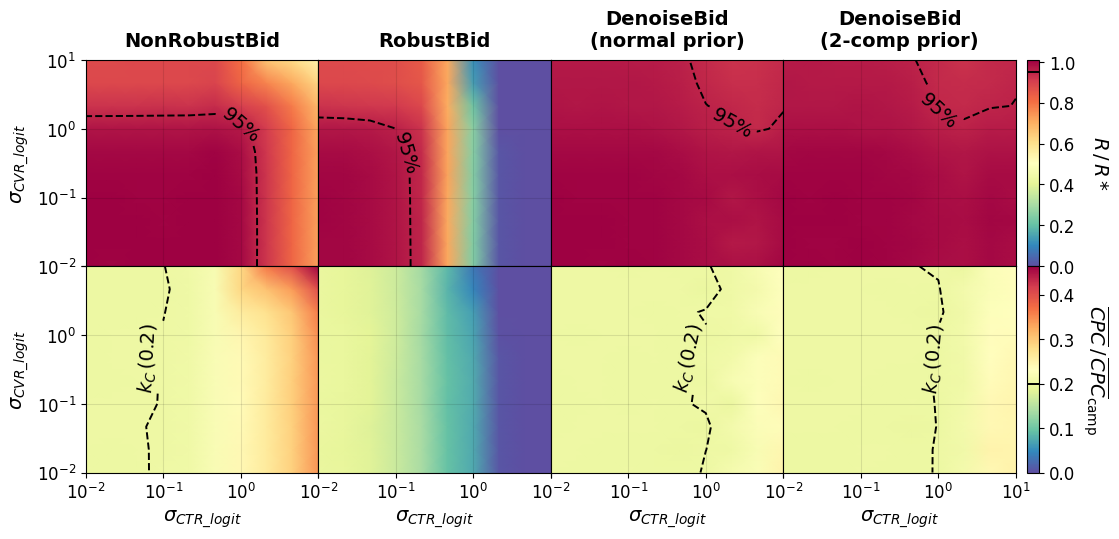

In [ ]:
metric_limits = []
for metric in metrics:
    col_name = f"{metric['name']}_mean"
    all_values = np.concatenate([df[col_name].values for df in dfs])
    g_min = np.nanmin(all_values)
    g_max = np.nanmax(all_values)
    metric_limits.append((g_min, g_max))

n_metrics = len(metrics)
n_bidders = len(dfs)

fig, axes = plt.subplots(
    nrows=n_metrics,
    ncols=n_bidders,
    figsize=(12, 5.5),
    sharex=True, 
    sharey=True,
)

axes = np.atleast_2d(axes)
if axes.shape != (n_metrics, n_bidders):
    axes = axes.reshape(n_metrics, n_bidders)

plt.subplots_adjust(wspace=0, hspace=0, top=0.85, bottom=0.1)

for j, metric in enumerate(metrics):
    vmin, vmax = metric_limits[j]

    for i, df in enumerate(dfs):
        ax = axes[j, i]
        
        pivot = df.pivot(
            index="sigma_cvr",
            columns="sigma_ctr",
            values=f"{metric['name']}_mean"
        ).sort_index(ascending=True).sort_index(axis=1, ascending=True)

        X_vals = pivot.columns.values
        Y_vals = pivot.index.values
        Z = pivot.values
        X_grid, Y_grid = np.meshgrid(X_vals, Y_vals)

        im = ax.pcolormesh(
            X_grid, Y_grid, Z,
            shading='gouraud',
            cmap="Spectral_r",
            vmin=vmin, vmax=vmax
        )

        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.minorticks_off()
        ax.grid(True, which="major", linestyle="-", alpha=0.1, color='black')

        if j == 0:
            ax.set_title(c_arr[i], fontsize=14, fontweight='bold', pad=10)
        
        if i == 0:
            ax.tick_params(labelsize=12)
            ax.set_ylabel("$\\sigma_{CVR\\_logit}$", fontsize=14)
            
        if j == n_metrics - 1:
            ax.tick_params(labelsize=12)
            ax.set_xlabel("$\\sigma_{CTR\\_logit}$", fontsize=14)

        if i == n_bidders - 1:
            cax = ax.inset_axes([1.05, 0.0, 0.05, 1.0])
            cbar = fig.colorbar(im, cax=cax, orientation='vertical')
            cbar.ax.tick_params(labelsize=12)
            cbar.set_label(metric["ylabel"], fontsize=14, fontweight='bold', rotation=270, labelpad=25)

        if metric["name"] == "total_conversions":
            Z_smoothed = gaussian_filter(Z, sigma=0.5)
            cs = ax.contour(
                X_grid, Y_grid, Z_smoothed,
                levels=[0.95],
                colors="black",
                linewidths=1.4,
                alpha=1,
                linestyles='dashed',
            )
            ax.clabel(cs, inline=True, fontsize=14, fmt={0.95: '$95\\%$'})
            if i == n_bidders - 1:
                cbar.ax.axhline(
                    0.95,
                    color='black',
                    linewidth=1.4,
                    alpha=1
                )

        if metric["name"] == "avg_cpc":
            Z_smoothed = gaussian_filter(Z, sigma=0.55)
            cs = ax.contour(
                X_grid, Y_grid, Z_smoothed,
                levels=[TARGET_CPC_PROPORTION],
                colors="black", linewidths=1.4,
                alpha=1,
                linestyles='dashed',
            )
            lbs = ax.clabel(cs, inline=True, fontsize=14, fmt={TARGET_CPC_PROPORTION: f'$k_C\\,(0.2)$'})
            if i == n_bidders - 1:
                cbar.ax.axhline(
                    TARGET_CPC_PROPORTION,
                    color='black',
                    linewidth=1.4,
                    alpha=1
                )

fig.canvas.draw() 

for j in range(n_metrics):
    for i in range(n_bidders):
        ax = axes[j, i]
        
        if i > 0:
            ax.tick_params(axis='y', which='both', left=False, right=False, labelleft=False)
            for label in ax.get_yticklabels():
                label.set_visible(False)
            
            ax.yaxis.get_offset_text().set_visible(False)

        if j < n_metrics - 1:
            ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
            for label in ax.get_xticklabels():
                label.set_visible(False)
            ax.xaxis.get_offset_text().set_visible(False)

        if j == n_metrics - 1 and i < n_bidders - 1:
            xmax = ax.get_xlim()[1]
            for label in ax.get_xticklabels():
                if not label.get_visible(): continue
                pos = label.get_position()[0]
                if np.isclose(pos, xmax, rtol=1e-1):
                    label.set_visible(False)

        if i == 0 and j > 0:
            ymax = ax.get_ylim()[1]
            for label in ax.get_yticklabels():
                if not label.get_visible(): continue
                pos = label.get_position()[1]
                if np.isclose(pos, ymax, rtol=1e-1):
                    label.set_visible(False)

plt.savefig(name_fig, format="pdf", bbox_inches="tight")
plt.show()